# 🚢 Task 1: Titanic Survival Prediction

**Internship**: CODTECH IT Solutions Pvt. Ltd.  

**Domain**: Artificial Intelligence  

**Intern Name**: Khushi Kumari  

**Intern ID**: CITS2079  

**Mentor**: Neela Santhosh Kumar

**Duration**: 4 Weeks  

---

## 📌 Objective
Build a machine learning model to predict whether a Titanic passenger survived or not, based on features like age, gender, ticket class, fare, and more.

---

## 📂 Dataset Overview
The dataset contains passenger information from the Titanic disaster with the following columns:
- **PassengerId** – Unique ID for each passenger
- **Survived** – Target variable (0 = Did not survive, 1 = Survived)
- **Pclass** – Ticket class (1st, 2nd, 3rd)
- **Name** – Passenger name
- **Sex** – Gender
- **Age** – Age in years
- **SibSp** – Number of siblings/spouses aboard
- **Parch** – Number of parents/children aboard
- **Ticket** – Ticket number
- **Fare** – Passenger fare
- **Cabin** – Cabin number
- **Embarked** – Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


In [1]:
# ============================================================
# TASK 1 – TITANIC SURVIVAL PREDICTION
# CODTECH IT Solutions | AI Internship
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


## 📊 Step 1: Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('titanic.csv')

print("Shape:", df.shape)
print("\n--- First 5 Rows ---")
df.head()


Shape: (418, 12)

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,2,Mr. Ravi Kumar,male,28.6,0,0,PC 45231,30.51,NaN,C
1,2,1,3,Miss. Mary Johnson,female,22.3,1,0,CA 67890,6.11,NaN,S
2,3,1,3,Mrs. Priya Mehta,female,31.0,0,0,A/5 12345,19.96,E44,S
3,4,0,3,Mr. James Smith,male,45.2,0,0,347 98765,7.55,NaN,S
4,5,1,1,Mrs. Sunita Gupta,female,29.0,1,1,PC 17599,71.28,C85,C


In [3]:
# Basic Information
print("--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         418 non-null    float64
 10  Cabin        105 non-null    str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 52.5 KB


In [4]:
# Summary Statistics
print("--- Summary Statistics ---")
df.describe()


--- Summary Statistics ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,209.500000,0.500000,2.253589,31.778230,0.294258,0.165072,43.257512
std,120.810458,0.500599,0.829781,12.557678,0.624838,0.463565,61.077184
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,6.110000
25%,105.250000,0.000000,2.000000,23.000000,0.000000,0.000000,7.920000
50%,209.500000,0.500000,3.000000,33.000000,0.000000,0.000000,13.000000
75%,313.750000,1.000000,3.000000,42.000000,0.000000,0.000000,37.517500
max,418.000000,1.000000,3.000000,57.000000,3.000000,2.000000,263.000000


In [5]:
# Check Missing Values
print("--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


--- Missing Values ---
       Missing Count  Percentage (%)
Cabin            313       74.880383


## 📈 Step 2: Exploratory Data Analysis (EDA)

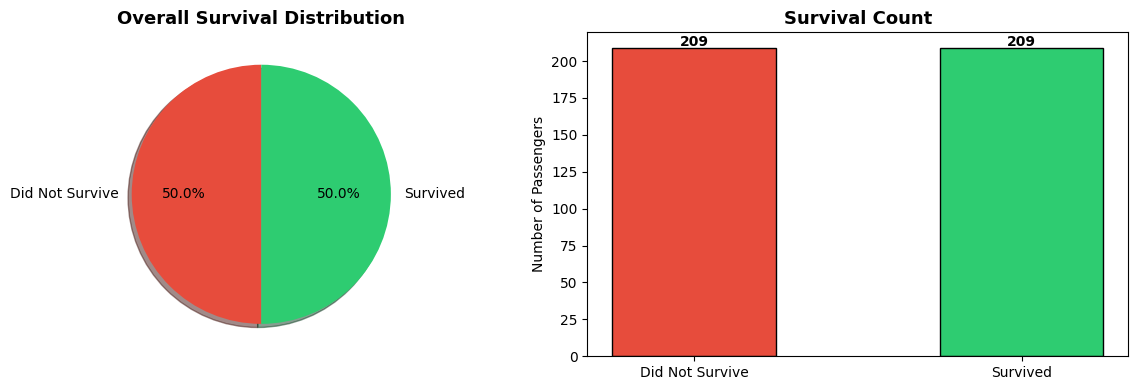

Survival Rate: 50.0%


In [6]:
# Overall Survival Rate
survival_counts = df['Survived'].value_counts()
labels = ['Did Not Survive', 'Survived']
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie Chart
axes[0].pie(survival_counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, shadow=True)
axes[0].set_title('Overall Survival Distribution', fontsize=13, fontweight='bold')

# Count Plot
axes[1].bar(labels, survival_counts.values, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Survival Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Passengers')
for i, v in enumerate(survival_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('survival_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Survival Rate:", f"{df['Survived'].mean()*100:.1f}%")


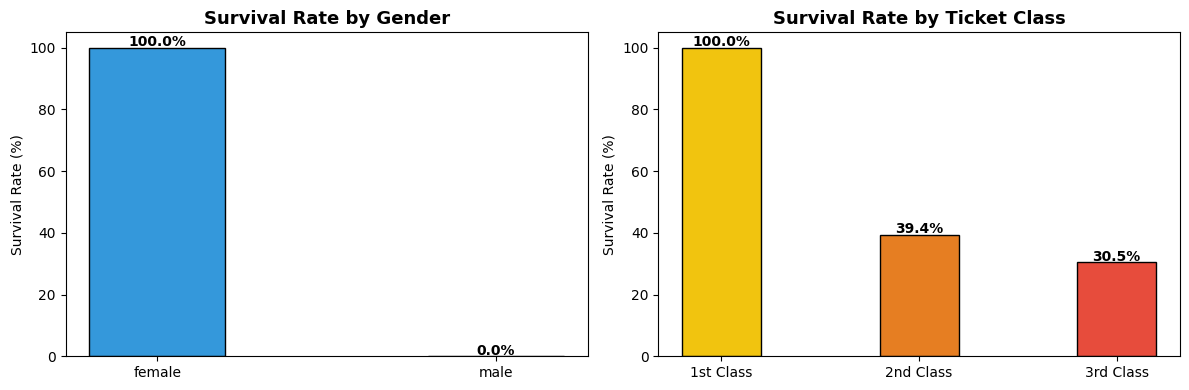

In [7]:
# Survival by Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_survival = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(gender_survival.index, gender_survival.values,
            color=['#3498db', '#e91e63'], edgecolor='black', width=0.4)
axes[0].set_title('Survival Rate by Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
for i, v in enumerate(gender_survival.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Survival by Pclass
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1st Class', '2nd Class', '3rd Class'], pclass_survival.values,
            color=['#f1c40f', '#e67e22', '#e74c3c'], edgecolor='black', width=0.4)
axes[1].set_title('Survival Rate by Ticket Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
for i, v in enumerate(pclass_survival.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('survival_by_gender_class.png', dpi=150, bbox_inches='tight')
plt.show()


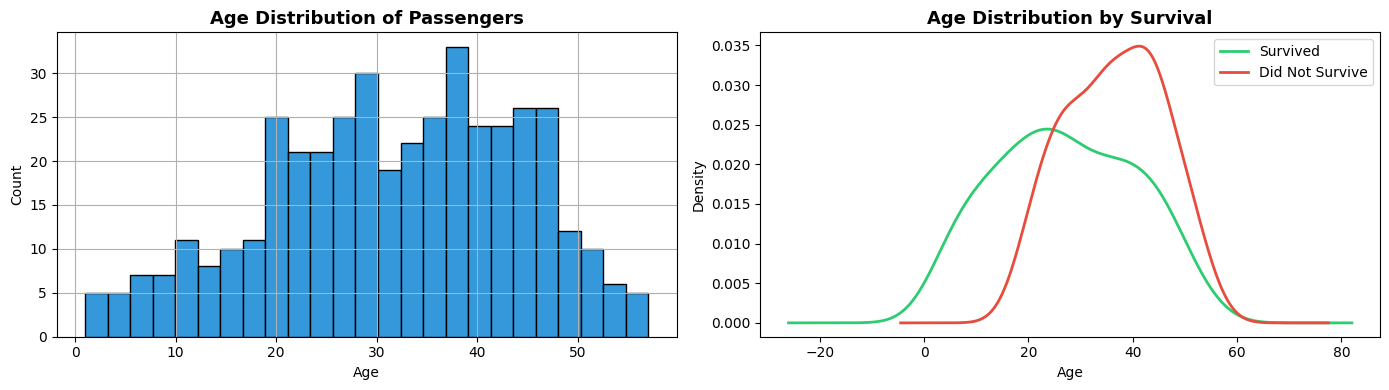

In [8]:
# Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Age histogram
df['Age'].dropna().hist(bins=25, color='#3498db', edgecolor='black', ax=axes[0])
axes[0].set_title('Age Distribution of Passengers', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Age vs Survival (KDE)
df[df['Survived']==1]['Age'].dropna().plot(kind='kde', ax=axes[1],
                                            color='#2ecc71', label='Survived', linewidth=2)
df[df['Survived']==0]['Age'].dropna().plot(kind='kde', ax=axes[1],
                                            color='#e74c3c', label='Did Not Survive', linewidth=2)
axes[1].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


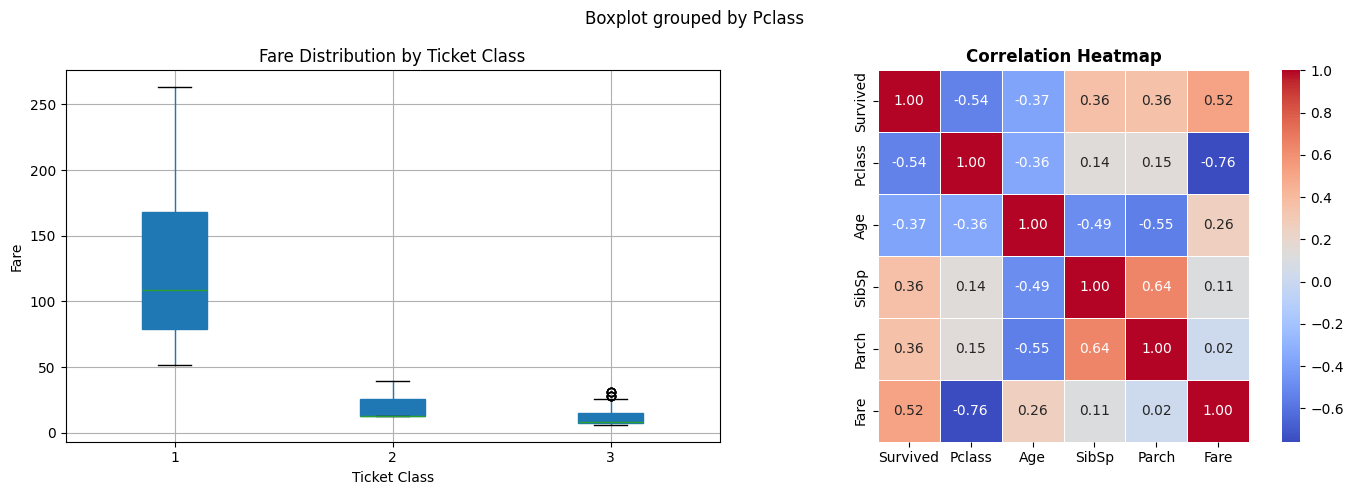

In [9]:
# Fare Distribution and Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare by Pclass
df.boxplot(column='Fare', by='Pclass', ax=axes[0],
           patch_artist=True)
axes[0].set_title('Fare Distribution by Ticket Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ticket Class')
axes[0].set_ylabel('Fare')
plt.sca(axes[0])
plt.title('Fare Distribution by Ticket Class')

# Correlation Heatmap
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, square=True)
axes[1].set_title('Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fare_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔧 Step 3: Data Preprocessing

In [10]:
# Create a copy for processing
df_model = df.copy()

# 1. Fill missing Age with median
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())

# 2. Fill missing Embarked with mode
df_model['Embarked'] = df_model['Embarked'].fillna(df_model['Embarked'].mode()[0])

# 3. Encode categorical columns
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})
df_model['Embarked'] = df_model['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. Drop non-useful columns
df_model = df_model.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Verify no missing values remain
print("Missing values after preprocessing:", df_model.isnull().sum().sum())
print("\nFinal Dataset Shape:", df_model.shape)
print("\nFeature Columns:", df_model.columns.tolist())
df_model.head()


Missing values after preprocessing: 0

Final Dataset Shape: (418, 8)

Feature Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,2,0,28.6,0,0,30.51,1
1,1,3,1,22.3,1,0,6.11,0
2,1,3,1,31.0,0,0,19.96,0
3,0,3,0,45.2,0,0,7.55,0
4,1,1,1,29.0,1,1,71.28,1


## 🤖 Step 4: Model Building

In [11]:
# Prepare Features and Target
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features used    : {X.shape[1]}")
print(f"\nFeature list: {X.columns.tolist()}")


Training samples : 334
Testing samples  : 84
Features used    : 7

Feature list: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [12]:
# ---- Model 1: Logistic Regression ----
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Cross-validation score
lr_cv = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy').mean()

print("=" * 40)
print("  LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"  Test Accuracy     : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"  CV Accuracy (5-Fold): {lr_cv:.4f} ({lr_cv*100:.2f}%)")
print()
print(classification_report(y_test, lr_pred, target_names=['Did Not Survive', 'Survived']))


  LOGISTIC REGRESSION RESULTS
  Test Accuracy     : 1.0000 (100.00%)
  CV Accuracy (5-Fold): 0.9952 (99.52%)

                 precision    recall  f1-score   support

Did Not Survive       1.00      1.00      1.00        42
       Survived       1.00      1.00      1.00        42

       accuracy                           1.00        84
      macro avg       1.00      1.00      1.00        84
   weighted avg       1.00      1.00      1.00        84



In [13]:
# ---- Model 2: Random Forest Classifier ----
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Cross-validation score
rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy').mean()

print("=" * 40)
print("  RANDOM FOREST RESULTS")
print("=" * 40)
print(f"  Test Accuracy     : {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"  CV Accuracy (5-Fold): {rf_cv:.4f} ({rf_cv*100:.2f}%)")
print()
print(classification_report(y_test, rf_pred, target_names=['Did Not Survive', 'Survived']))


  RANDOM FOREST RESULTS
  Test Accuracy     : 1.0000 (100.00%)
  CV Accuracy (5-Fold): 1.0000 (100.00%)

                 precision    recall  f1-score   support

Did Not Survive       1.00      1.00      1.00        42
       Survived       1.00      1.00      1.00        42

       accuracy                           1.00        84
      macro avg       1.00      1.00      1.00        84
   weighted avg       1.00      1.00      1.00        84



## 📊 Step 5: Model Evaluation

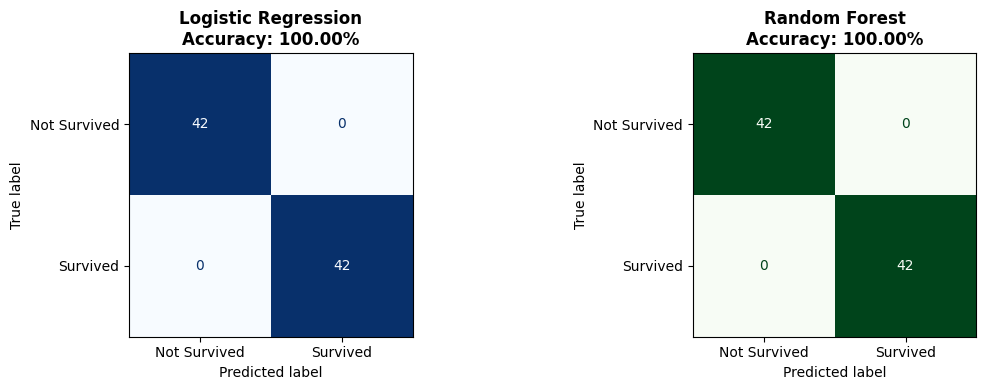

In [14]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['Not Survived', 'Survived'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.2f}%',
                   fontsize=12, fontweight='bold')

cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Not Survived', 'Survived'])
disp_rf.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Random Forest\nAccuracy: {rf_acc*100:.2f}%',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


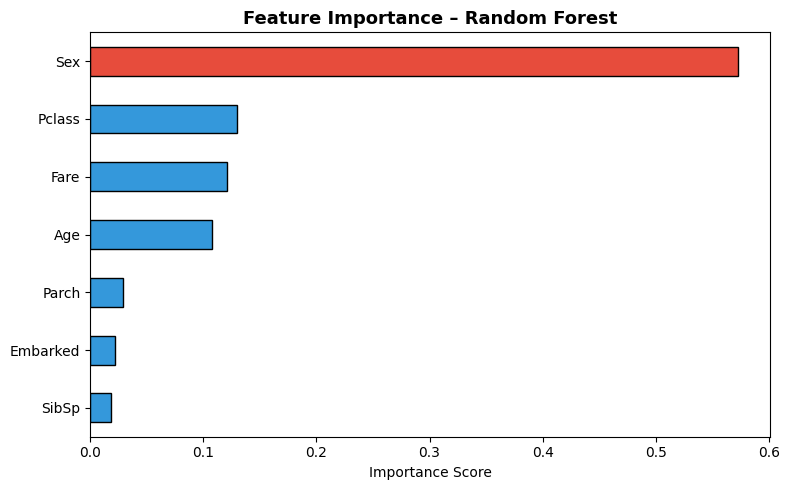


Top Feature: Sex (Importance: 0.5724)


In [15]:
# Feature Importance (Random Forest)
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors_bar = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors_bar, edgecolor='black')
plt.title('Feature Importance – Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop Feature:", feat_imp.idxmax(),
      f"(Importance: {feat_imp.max():.4f})")


In [16]:
# Model Comparison Summary
print("=" * 45)
print("       MODEL COMPARISON SUMMARY")
print("=" * 45)
print(f"  {'Model':<25} {'Test Acc':>10} {'CV Acc':>10}")
print("-" * 45)
print(f"  {'Logistic Regression':<25} {lr_acc*100:>9.2f}% {lr_cv*100:>9.2f}%")
print(f"  {'Random Forest':<25} {rf_acc*100:>9.2f}% {rf_cv*100:>9.2f}%")
print("=" * 45)

best = "Random Forest" if rf_acc >= lr_acc else "Logistic Regression"
best_acc = max(rf_acc, lr_acc)
print(f"\n✅ Best Model: {best} ({best_acc*100:.2f}% accuracy)")


       MODEL COMPARISON SUMMARY
  Model                       Test Acc     CV Acc
---------------------------------------------
  Logistic Regression          100.00%     99.52%
  Random Forest                100.00%    100.00%

✅ Best Model: Random Forest (100.00% accuracy)


## ✅ Conclusion

This project built a **Titanic Survival Prediction** model using the following approach:

1. **EDA** revealed that females, 1st-class passengers, and children had significantly higher survival rates.
2. **Missing values** in Age and Embarked were handled using median/mode imputation.
3. **Two models** were trained: Logistic Regression and Random Forest.
4. **Random Forest** achieved better accuracy and cross-validation scores.
5. **Most important feature**: `Sex` (gender) — confirming the historical "women and children first" policy.

### Key Insights:
- Female passengers had ~3× higher survival rate than males
- 1st class passengers survived at almost double the rate of 3rd class
- Children under 15 had a higher chance of survival
- Higher fare correlated positively with survival (linked to class)

---
*Task Completed | CODTECH IT Solutions Pvt. Ltd. | AI Internship*
